## Data Collection

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


## EDA

In [3]:
df.shape

(37249, 2)

In [4]:
df.sample() # It will get a random selection every time you run


,clean_comment,category
10736,interesting question and suprisingly think mod...,1


In [5]:
df.sample()['clean_comment'].values

<ArrowStringArray>
['lol get ready suck the dick ']
Length: 1, dtype: str

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   clean_comment  37149 non-null  str  
 1   category       37249 non-null  int64
dtypes: int64(1), str(1)
memory usage: 7.0 MB


In [7]:
df.isnull().sum()

clean_comment    100
category           0
dtype: int64

In [8]:
df[df['clean_comment'].isna()] # Thos line will display the null samples of 'clean_comment' row

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [9]:
df.duplicated().sum()

np.int64(449)

In [10]:
df[df.duplicated()]

,clean_comment,category
375,,0
392,,0
605,NaN,0
617,aurum mom,0
651,,0
...,...,...
37111,NaN,0
37125,hari,0
37158,top kek,1
37234,this part series minute videos focusing each d...,1


In [11]:
## Drop null values from the dataset

df.dropna(inplace=True) # Inplace means the modification of the df on the same df, but inplace = flase means pandas ignores the orignal df and create new copy of df and apply the modification

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df[(df["clean_comment"].str.strip() == "")] # This line will display the empty samples of 'clean_comment' row, str.strip() is used to remove the leading and trailing spaces from the string, and then it checks if the resulting string is empty ("").

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [14]:
# Identify rows where clean_comment is empty after stripping spaces
empty_mask = df["clean_comment"].str.strip() == ""

In [15]:
empty_mask

0        False
1        False
2        False
3        False
4        False
         ...  
37244    False
37245    False
37246    False
37247    False
37248    False
Name: clean_comment, Length: 36799, dtype: bool

In [16]:
# Keep only rows that are NOT empty
df = df[~empty_mask]

In [17]:
"Keep rows where clean_comment is not empty"
# Best readable version
valid_comment_mask = df["clean_comment"].str.strip() != ""
df = df[valid_comment_mask]
df

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37244,jesus,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [18]:
# Convert the 'clean_comment' column to lowercase
df["clean_comment"] = df["clean_comment"].str.lower()

# Verify the transformation by displaying the first few rows
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [19]:
# Check for leading or trailing spaces in 'clean_comment' column
df[df["clean_comment"].apply(lambda x: x.endswith(" ") or x.startswith(" "))]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [20]:
# Remove trailing and leading whitespaces from the 'clean_comment' column
df["clean_comment"] = df["clean_comment"].str.strip()

# Verify the transformation by checking for any remaining trailing whitespaces
df["clean_comment"].apply(lambda x: x.endswith(" ") or x.startswith(" ")).sum()

np.int64(0)

In [21]:
# Identify comments containing URLs
url_pattern = (
    r"http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+"
)
comments_with_urls = df[df["clean_comment"].str.contains(url_pattern, regex=True)]

# Display the comments containing URLs
comments_with_urls.head()

,clean_comment,category


In [22]:
# Cleaner version
url_mask = df["clean_comment"].str.contains(url_pattern, regex=True, na=False)
comments_with_urls = df[url_mask]
comments_with_urls.head()

,clean_comment,category


In [23]:
# Identify comments containing new line characters
comments_with_newline = df[df["clean_comment"].str.contains("\n")]

# Display the comments containing new line characters
comments_with_newline.head()

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1


In [24]:
# Remove new line characters from the 'clean_comment' column
df["clean_comment"] = df["clean_comment"].str.replace("\n", " ", regex=True)

# Verify the transformation by checking for any remaining new lines
comments_with_newline_remaining = df[df["clean_comment"].str.contains("\n")]
comments_with_newline_remaining

,clean_comment,category


## Visualization

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

### 1. Class Distribution

In [26]:
df["category"] = df["category"].map(
    {1: "positive", 
     0: "neutral", 
     -1: "negative"})

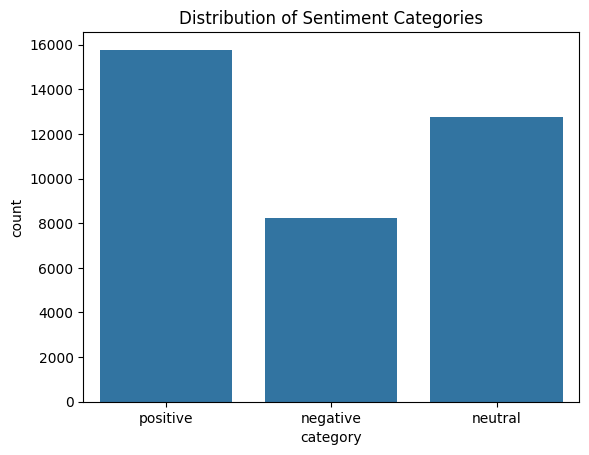

In [27]:
sns.countplot(data=df, x='category')
plt.title('Distribution of Sentiment Categories')
plt.show()

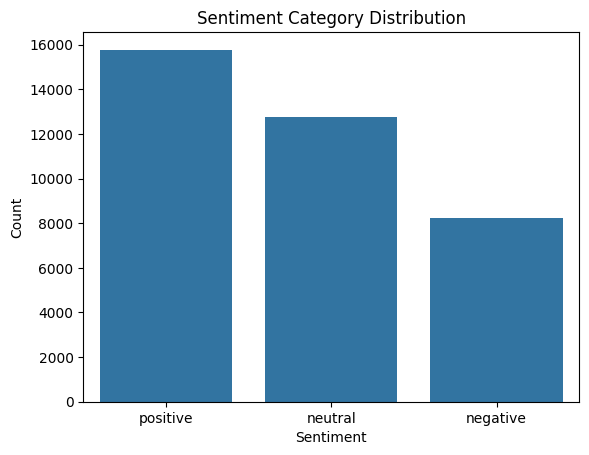

In [28]:
sns.countplot(data=df, x="category", order=df["category"].value_counts().index)
plt.title("Sentiment Category Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

### 2. Comment Length Distribution

In [29]:
df["char_count"] = df["clean_comment"].str.len()
df["word_count"] = df["clean_comment"].str.split().str.len()

In [30]:
df["char_count"]

0         259
1        1268
2         459
3         167
4         690
         ... 
37244       5
37245      99
37246      36
37247       9
37248      37
Name: char_count, Length: 36793, dtype: int64

In [31]:
df["char_count"].describe()

count    36793.000000
mean       181.852798
std        359.702163
min          1.000000
25%         38.000000
50%         80.000000
75%        184.000000
max       8664.000000
Name: char_count, dtype: float64

In [32]:
df["word_count"]

0         39
1        196
2         86
3         29
4        112
        ... 
37244      1
37245     19
37246      6
37247      2
37248      6
Name: word_count, Length: 36793, dtype: int64

#### Add word_count and char_count columns

In [33]:
df["word_count"] = df["clean_comment"].str.split().str.len()
df["char_count"] = df["clean_comment"].str.len()
df.head()

,clean_comment,category,char_count,word_count
0,family mormon have never tried explain them th...,positive,259,39
1,buddhism has very much lot compatible with chr...,positive,1268,196
2,seriously don say thing first all they won get...,negative,459,86
3,what you have learned yours and only yours wha...,neutral,167,29
4,for your own benefit you may want read living ...,positive,690,112


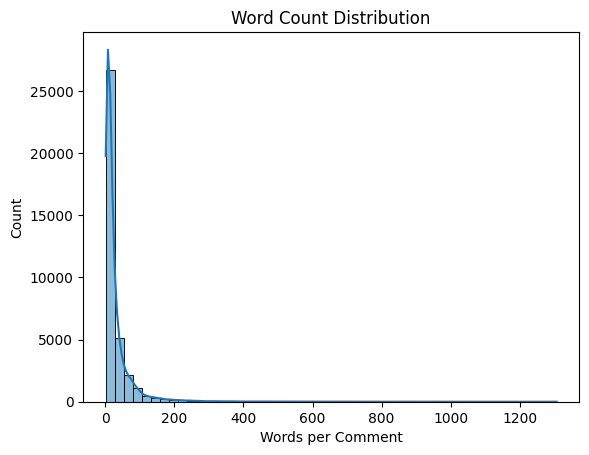

In [34]:
sns.histplot(df["word_count"], bins=50, kde=True)
plt.title("Word Count Distribution")
plt.xlabel("Words per Comment")
plt.show()

### 3. Word Count by Sentiment

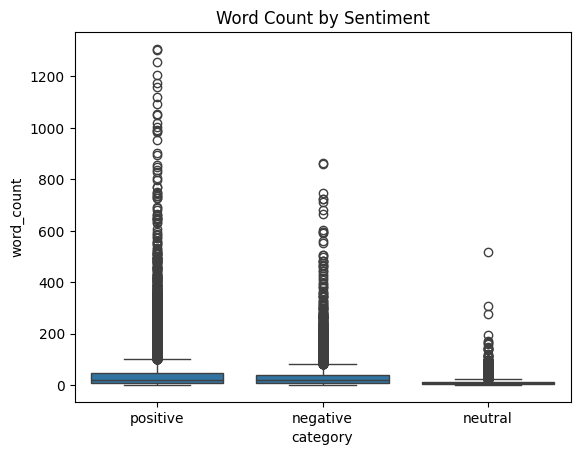

In [35]:
sns.boxplot(data=df, x="category", y="word_count")
plt.title("Word Count by Sentiment")
plt.show()

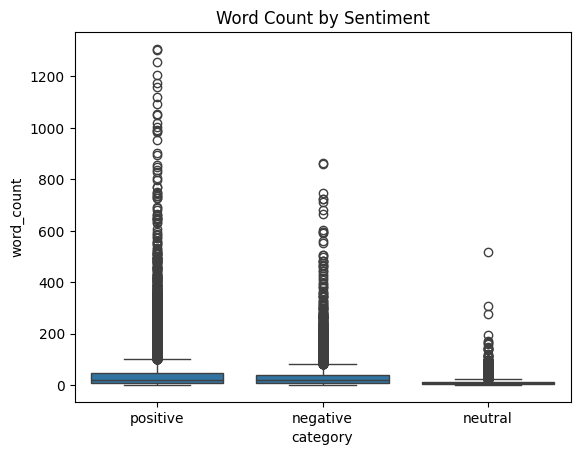

In [36]:
df["word_count"] = df["clean_comment"].str.split().str.len()

sns.boxplot(data=df, x="category", y="word_count")
plt.title("Word Count by Sentiment")
plt.show()

### 4. Character Count by Sentiment

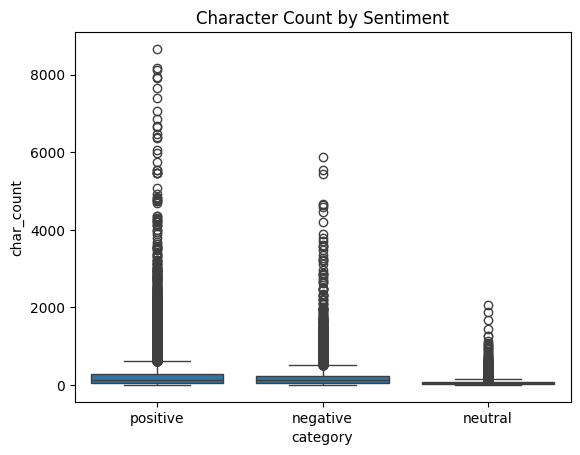

In [37]:
sns.boxplot(data=df, x='category', y='char_count')
plt.title("Character Count by Sentiment")
plt.show()

### 5. Most Frequent Words
- This is where text visualization becomes insightful.

In [38]:
# Combine all text:
text = " ".join(df["clean_comment"])

In [39]:
# Count words:
from collections import Counter

word_freq = Counter(text.split())
common_words = pd.DataFrame(word_freq.most_common(20), columns=["word", "count"])

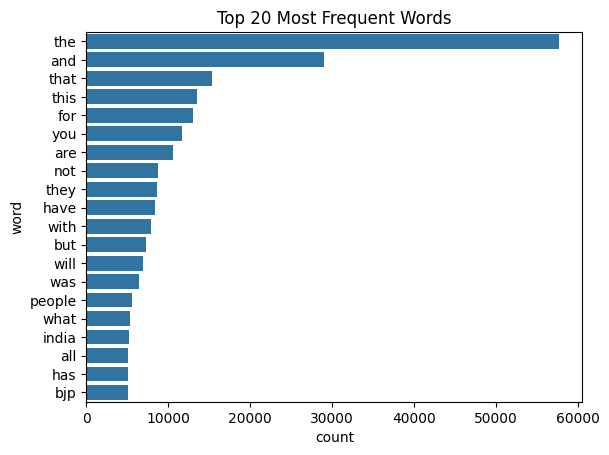

In [40]:
# Plot the most common words
sns.barplot(data=common_words, x="count", y="word")
plt.title("Top 20 Most Frequent Words")
plt.show()

### 6. Word Clouds

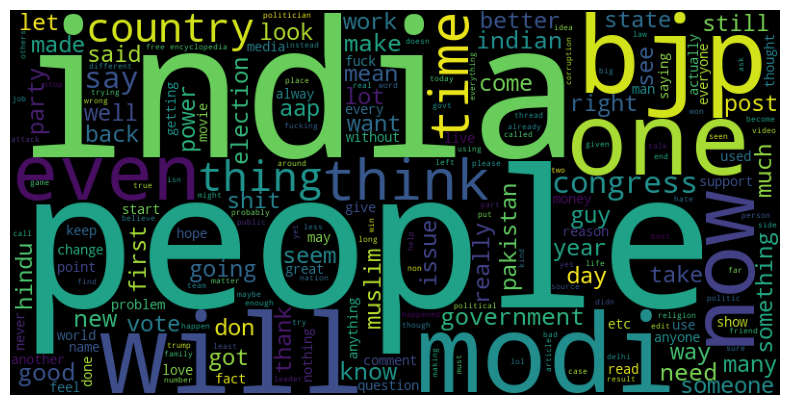

In [41]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

### 7. Word Clouds Per Sentiment

In [42]:
# Analyze positive comments separately

positive_text = " ".join(df[df["category"] == "positive"]["clean_comment"])
positive_text

'family mormon have never tried explain them they still stare puzzled from time time like some kind strange creature nonetheless they have come admire for the patience calmness equanimity acceptance and compassion have developed all the things buddhism teaches buddhism has very much lot compatible with christianity especially considering that sin and suffering are almost the same thing suffering caused wanting things shouldn want going about getting things the wrong way christian this would mean wanting things that don coincide with god will and wanting things that coincide but without the aid jesus buddhism could also seen proof god all mighty will and omnipotence certainly christians are lucky have one such christ there side but what about everyone else well many christians believe god grace salvation and buddhism god way showing grace upon others would also help study the things jesus said and see how buddha has made similar claims such rich man getting into heaven joke basically ad

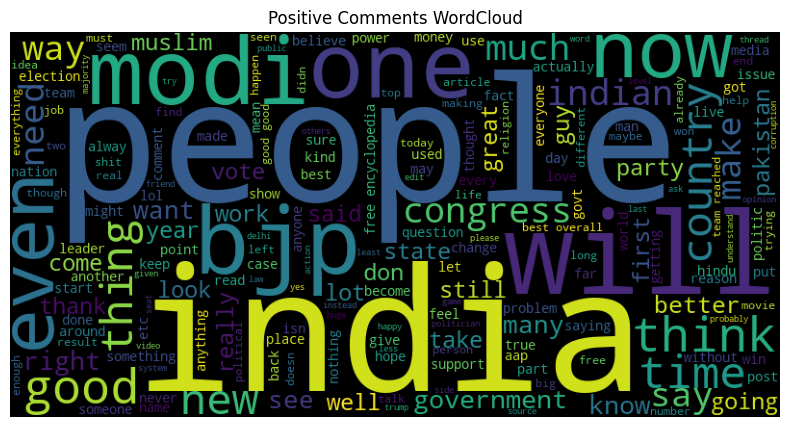

In [43]:
wordcloud = WordCloud(width=800, height=400).generate(positive_text)
# wordcloud = WordCloud(width=800, height=400).generate(" ".join(df[df["category"] == 1]["clean_comment"]))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Comments WordCloud")
plt.show()

### 8. Top Words by Sentiment

In [44]:
positive_text = " ".join(df[df["category"] == "positive"]["clean_comment"])
negative_text = " ".join(df[df["category"] == "negative"]["clean_comment"])

### 9. Correlation Heatmap of Engineered Features

In [45]:
df["char_count"]
df["word_count"]

0         39
1        196
2         86
3         29
4        112
        ... 
37244      1
37245     19
37246      6
37247      2
37248      6
Name: word_count, Length: 36793, dtype: int64

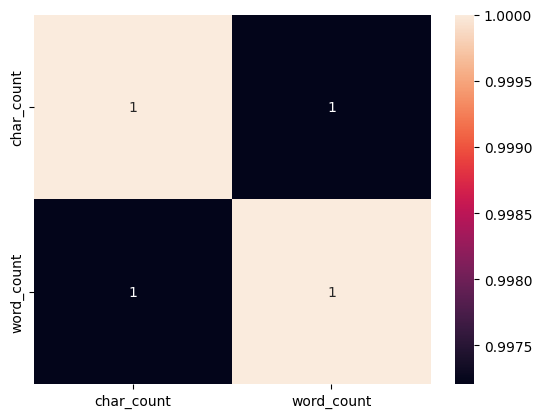

In [46]:
sns.heatmap(df[["char_count", "word_count"]].corr(), annot=True)
plt.show()

### 10. Sentiment Percentage Pie Chart

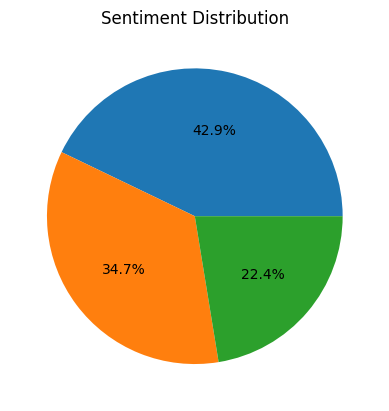

In [47]:
plt.pie(df["category"].value_counts(), autopct="%1.1f%%")
plt.title("Sentiment Distribution")
plt.ylabel("")
plt.show()

In [48]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))
# Display positive and negative text for analysis
df["num_stop_words"] = df["clean_comment"].apply(
    lambda text: sum(word in stop_words for word in text.split())
)
df.head

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<bound method NDFrame.head of                                            clean_comment  category  \
0      family mormon have never tried explain them th...  positive   
1      buddhism has very much lot compatible with chr...  positive   
2      seriously don say thing first all they won get...  negative   
3      what you have learned yours and only yours wha...   neutral   
4      for your own benefit you may want read living ...  positive   
...                                                  ...       ...   
37244                                              jesus   neutral   
37245  kya bhai pure saal chutiya banaya modi aur jab...  positive   
37246               downvote karna tha par upvote hogaya   neutral   
37247                                          haha nice  positive   
37248              facebook itself now working bjp’ cell   neutral   

       char_count  word_count  num_stop_words  
0             259          39              13  
1            1268         196    

In [49]:
df.head()

,clean_comment,category,char_count,word_count,num_stop_words
0,family mormon have never tried explain them th...,positive,259,39,13
1,buddhism has very much lot compatible with chr...,positive,1268,196,59
2,seriously don say thing first all they won get...,negative,459,86,40
3,what you have learned yours and only yours wha...,neutral,167,29,15
4,for your own benefit you may want read living ...,positive,690,112,45


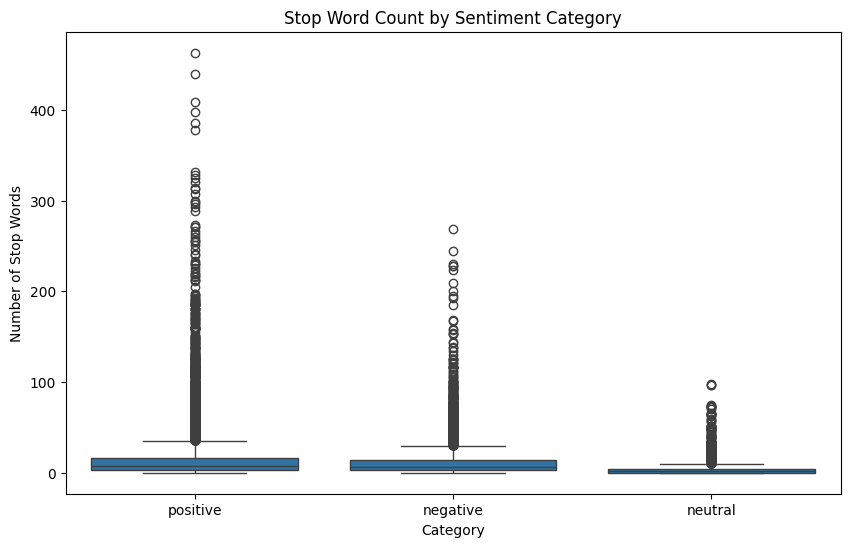

In [50]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="category", y="num_stop_words")
plt.title("Stop Word Count by Sentiment Category")
plt.xlabel("Category")
plt.ylabel("Number of Stop Words")
plt.show()

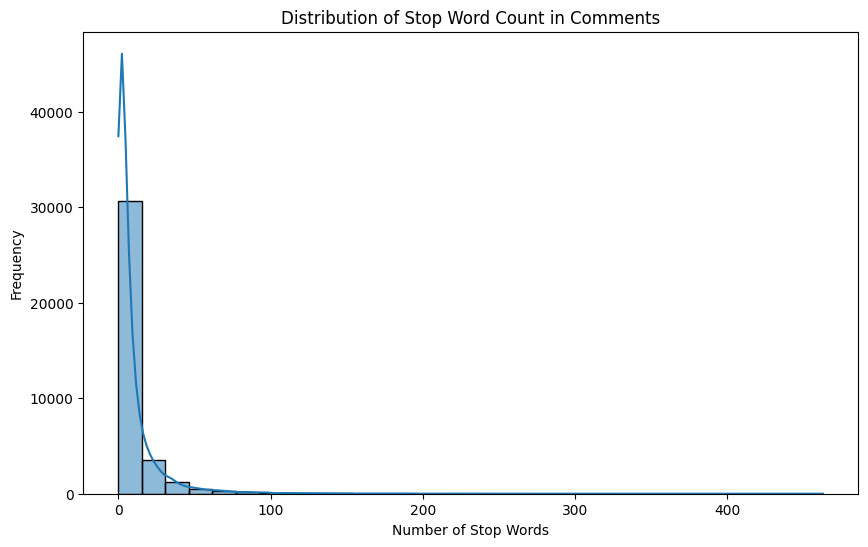

In [51]:
plt.figure(figsize=(10, 6))
sns.histplot(df["num_stop_words"], bins=30, kde=True)
plt.title("Distribution of Stop Word Count in Comments")
plt.xlabel("Number of Stop Words")
plt.ylabel("Frequency")
plt.show()

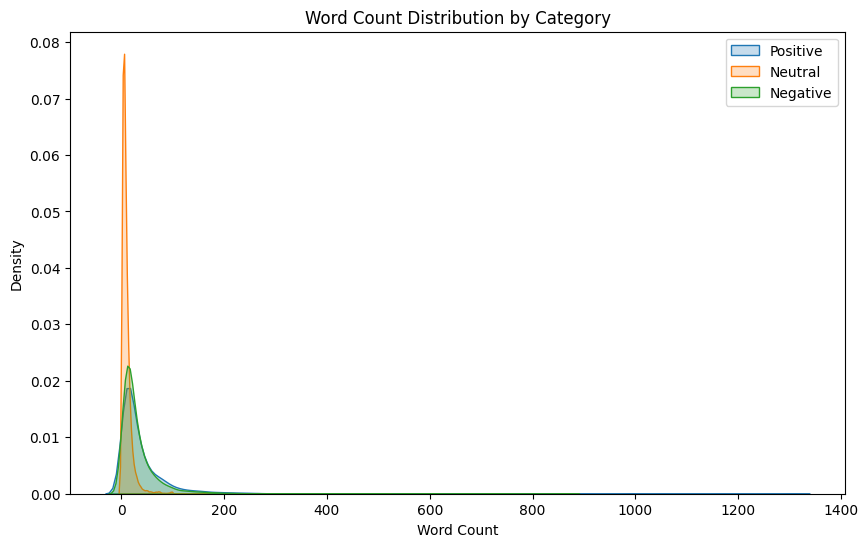

In [52]:
# Create the figure and axes
plt.figure(figsize=(10, 6))

# Plot KDE for category positive
sns.kdeplot(df[df["category"] == "positive"]["word_count"], label="Positive", fill=True)

# Plot KDE for category neutral
sns.kdeplot(df[df["category"] == "neutral"]["word_count"], label="Neutral", fill=True)

# Plot KDE for category negative
sns.kdeplot(df[df["category"] == "negative"]["word_count"], label="Negative", fill=True)

# Add title and labels
plt.title("Word Count Distribution by Category")
plt.xlabel("Word Count")
plt.ylabel("Density")

# Add a legend
plt.legend()

# Show the plot
plt.show()

<Axes: xlabel='category', ylabel='num_stop_words'>

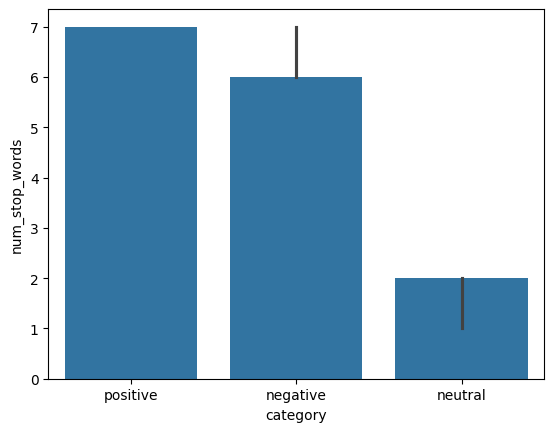

In [53]:
# median word counts among sentiments

sns.barplot(df, x="category", y="num_stop_words", estimator="median")

C:\Users\moham\AppData\Local\Temp\ipykernel_14468\21523039.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df, x="count", y="stop_word", palette="viridis")


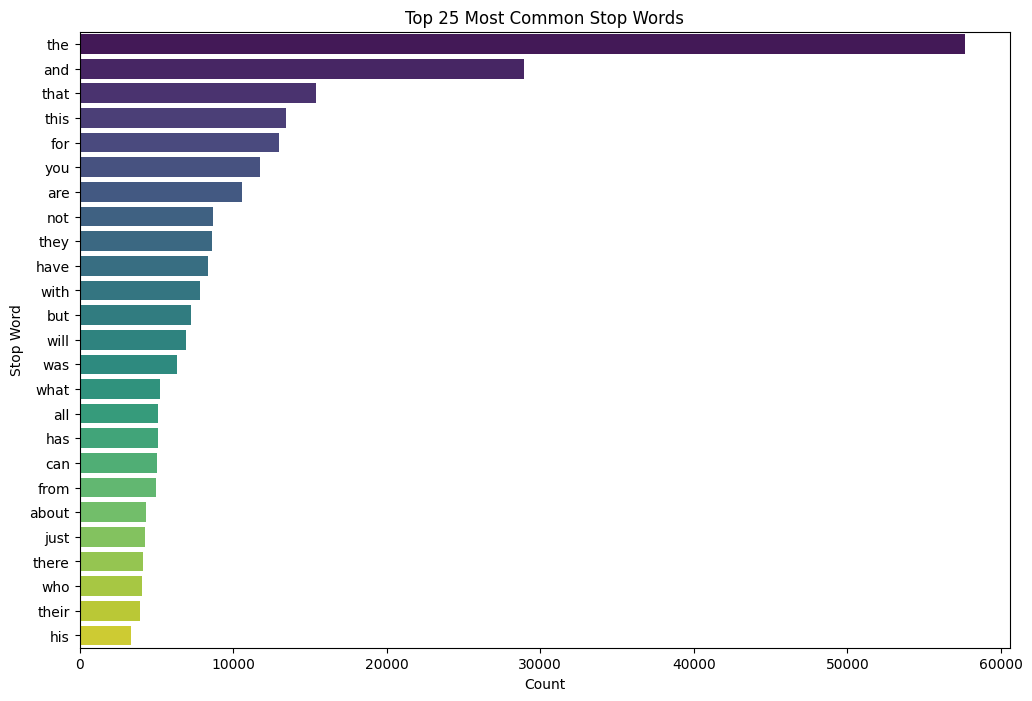

In [54]:
# Create a frequency distribution of stop words in the 'clean_comment' column
from collections import Counter

# Extract all stop words from the comments using the previously defined 'common_stopwords'
all_stop_words = [
    word
    for comment in df["clean_comment"]
    for word in comment.split()
    if word in stop_words
]

# Count the most common stop words
most_common_stop_words = Counter(all_stop_words).most_common(25)

# Convert the most common stop words to a DataFrame for plotting
top_25_df = pd.DataFrame(most_common_stop_words, columns=["stop_word", "count"])

# Create the barplot for the top 25 most common stop words
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_df, x="count", y="stop_word", palette="viridis")
plt.title("Top 25 Most Common Stop Words")
plt.xlabel("Count")
plt.ylabel("Stop Word")
plt.show()

In [55]:
# Add a new column for the number of characters in each comment
df["num_chars"] = df["clean_comment"].apply(len)

df.head()

,clean_comment,category,char_count,word_count,num_stop_words,num_chars
0,family mormon have never tried explain them th...,positive,259,39,13,259
1,buddhism has very much lot compatible with chr...,positive,1268,196,59,1268
2,seriously don say thing first all they won get...,negative,459,86,40,459
3,what you have learned yours and only yours wha...,neutral,167,29,15,167
4,for your own benefit you may want read living ...,positive,690,112,45,690


In [56]:
from collections import Counter
import pandas as pd

# Step 1: Combine all comments from the 'clean_comment' column into one long string
# Example:
# ["hello world", "good day"]  ->  "hello world good day"
all_text = " ".join(df["clean_comment"])

# Step 2: Count how many times each character appears in the combined text
# This includes letters, spaces, punctuation marks, etc.
# Example:
# "hello" -> {'h':1, 'e':1, 'l':2, 'o':1}
char_frequency = Counter(all_text)

# Step 3: Convert the character counts into a DataFrame
# Each row will contain:
# - the character
# - the number of times it appears
char_frequency_df = pd.DataFrame(
    char_frequency.items(), columns=["character", "frequency"]
)

# Step 4: Sort the DataFrame by frequency in descending order
# This puts the most frequent characters at the top
char_frequency_df = char_frequency_df.sort_values(by="frequency", ascending=False)

# Step 5: Display the top 10 most frequent characters
char_frequency_df.head(10)


# It is useful for detecting:

# punctuation patterns
# special symbols
# noisy characters
# cleaning needs

,character,frequency
6,,1091592
12,e,666610
13,t,491287
1,a,481134
3,i,401388
9,n,388465
7,o,379908
17,s,355279
8,r,331425
10,h,296748


In [57]:
char_frequency_df["character"].values

<ArrowStringArray>
[' ', 'e', 't', 'a', 'i', 'n', 'o', 's', 'r', 'h',
 ...
 '遥', '则', '豹', '皿', '煮', '唯', '统', '段', '她', '谁']
Length: 1378, dtype: str

In [58]:
char_frequency_df.tail(50)

,character,frequency
1286,货,1
1287,语,1
1312,耐,1
1313,精,1
342,━,1
345,⊂,1
346,゜,1
347,ｊ,1
1289,显,1
1291,鞋,1


In [59]:
# Create a new column 'num_punctuation_chars' to count punctuation characters in each comment
df["num_punctuation_chars"] = df["clean_comment"].apply(
    lambda x: sum([1 for char in x if char in ".,!?;:\"'()[]{}-"])
)

df.sample(5)

,clean_comment,category,char_count,word_count,num_stop_words,num_chars,num_punctuation_chars
510,apparently there love for lalafell these parts...,positive,163,28,9,163,0
22632,don let this wannabe dictator promises fool yo...,neutral,119,20,7,119,0
3769,wonder ever find out what union know tdb weapo...,neutral,144,26,12,144,0
8874,why are you trying change them the issue with ...,neutral,58,12,9,58,0
20227,agarwal likely play for kings know had amazing...,positive,62,10,2,62,0


In [60]:
df["num_punctuation_chars"].describe()

count    36793.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: num_punctuation_chars, dtype: float64

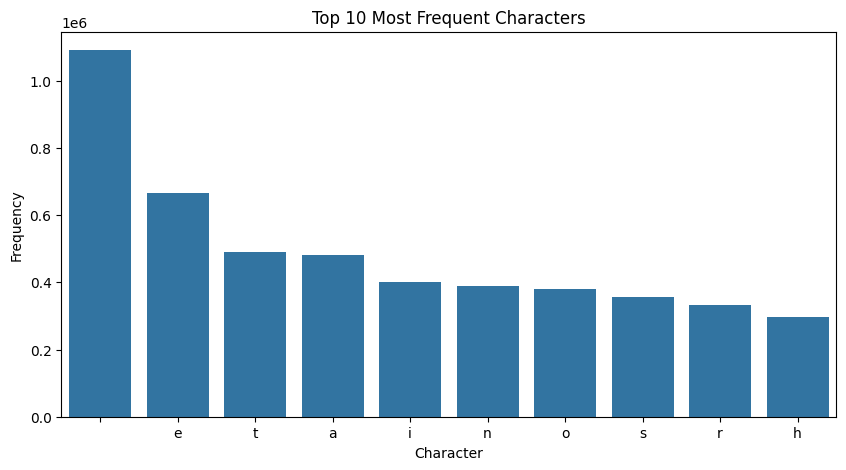

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

top_chars = char_frequency_df.head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_chars, x="character", y="frequency")
plt.title("Top 10 Most Frequent Characters")
plt.xlabel("Character")
plt.ylabel("Frequency")
plt.show()

C:\Users\moham\AppData\Local\Temp\ipykernel_14468\3949717198.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, x="count", y="bigram", palette="magma")


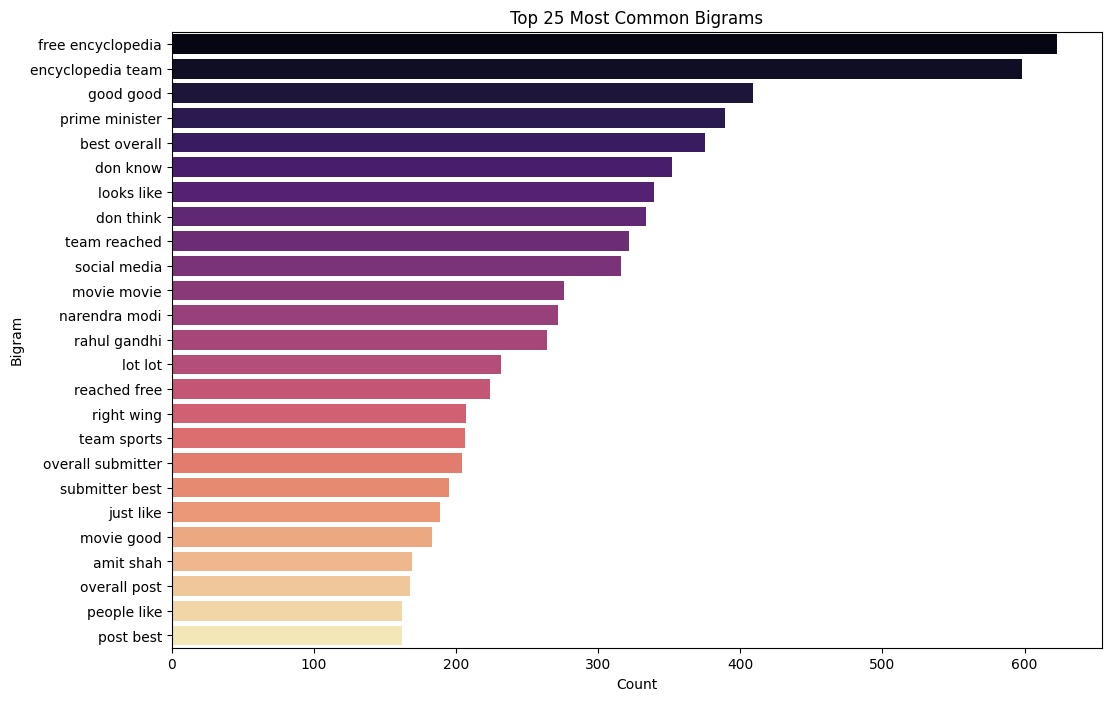

In [62]:
from sklearn.feature_extraction.text import CountVectorizer


# Create a function to extract the top 25 bigrams
def get_top_ngrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words="english").fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]


# Get the top 25 bigrams
top_25_bigrams = get_top_ngrams(df["clean_comment"], 25)

# Convert the bigrams into a DataFrame for plotting
top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns=["bigram", "count"])

# Plot the countplot for the top 25 bigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_bigrams_df, x="count", y="bigram", palette="magma")
plt.title("Top 25 Most Common Bigrams")
plt.xlabel("Count")
plt.ylabel("Bigram")
plt.show()

C:\Users\moham\AppData\Local\Temp\ipykernel_14468\3866209739.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_trigrams_df, x="count", y="trigram", palette="coolwarm")


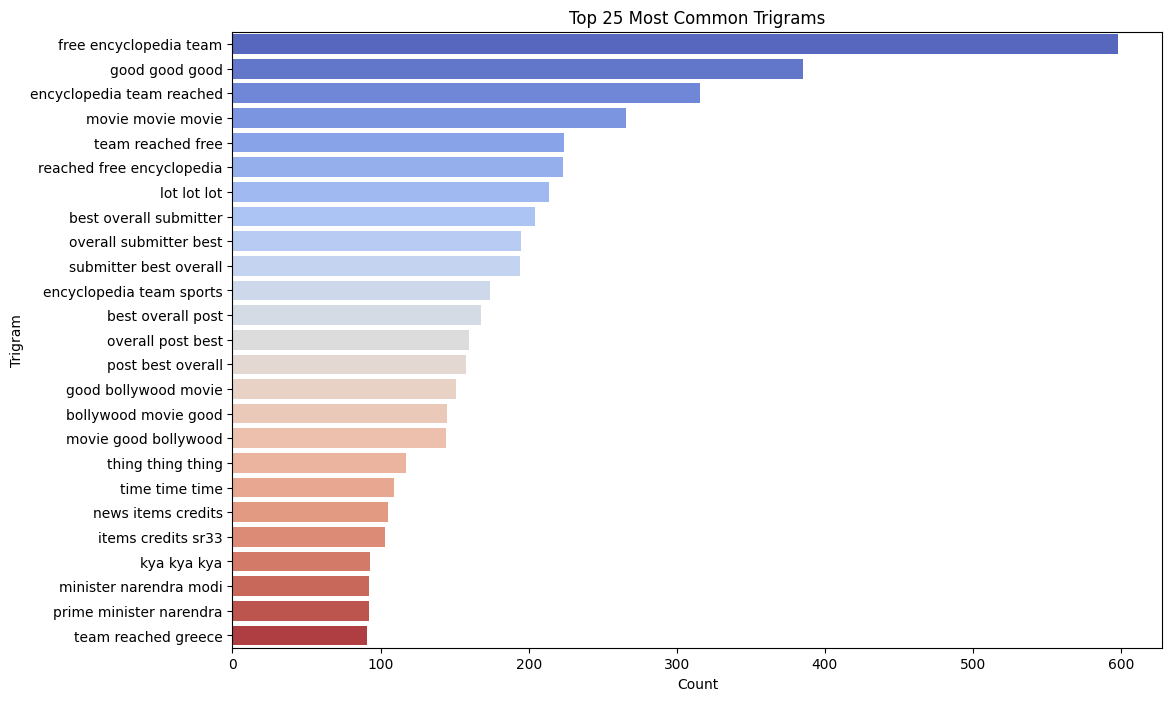

In [63]:
# Create a function to extract the top 25 trigrams
def get_top_trigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3), stop_words="english").fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]


# Get the top 25 trigrams
top_25_trigrams = get_top_trigrams(df["clean_comment"], 25)

# Convert the trigrams into a DataFrame for plotting
top_25_trigrams_df = pd.DataFrame(top_25_trigrams, columns=["trigram", "count"])

# Plot the countplot for the top 25 trigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_trigrams_df, x="count", y="trigram", palette="coolwarm")
plt.title("Top 25 Most Common Trigrams")
plt.xlabel("Count")
plt.ylabel("Trigram")
plt.show()

In [64]:
df.head()

,clean_comment,category,char_count,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon have never tried explain them th...,positive,259,39,13,259,0
1,buddhism has very much lot compatible with chr...,positive,1268,196,59,1268,0
2,seriously don say thing first all they won get...,negative,459,86,40,459,0
3,what you have learned yours and only yours wha...,neutral,167,29,15,167,0
4,for your own benefit you may want read living ...,positive,690,112,45,690,0


In [65]:
from nltk.corpus import stopwords

# Step 1: Load English stop words
stop_words = set(stopwords.words("english"))

# Step 2: Keep important sentiment words by removing them from the stop word list
# These words are useful for sentiment analysis because they affect meaning
important_words = {"not", "but", "however", "no", "yet"}
stop_words = stop_words - important_words

# Step 3: Remove stop words from each comment while keeping important sentiment words
df["clean_comment"] = df["clean_comment"].apply(
    lambda text: " ".join(
        word for word in text.split() if word.lower() not in stop_words
    )
)

df.head()

,clean_comment,category,char_count,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,positive,259,39,13,259,0
1,buddhism much lot compatible christianity espe...,positive,1268,196,59,1268,0
2,seriously say thing first get complex explain ...,negative,459,86,40,459,0
3,learned want teach different focus goal not wr...,neutral,167,29,15,167,0
4,benefit may want read living buddha living chr...,positive,690,112,45,690,0


In [66]:
import nltk
from nltk.stem import WordNetLemmatizer

# Ensure required NLTK data is available
nltk.download("wordnet")

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()


# Function to lemmatize a sentence
def lemmatize_text(text):
    if not isinstance(text, str):
        return text
    return " ".join(lemmatizer.lemmatize(word) for word in text.split())


# Apply to dataframe column
df["clean_comment"] = df["clean_comment"].apply(lemmatize_text)

# Preview result
df.head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_comment,category,char_count,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,positive,259,39,13,259,0
1,buddhism much lot compatible christianity espe...,positive,1268,196,59,1268,0
2,seriously say thing first get complex explain ...,negative,459,86,40,459,0
3,learned want teach different focus goal not wr...,neutral,167,29,15,167,0
4,benefit may want read living buddha living chr...,positive,690,112,45,690,0


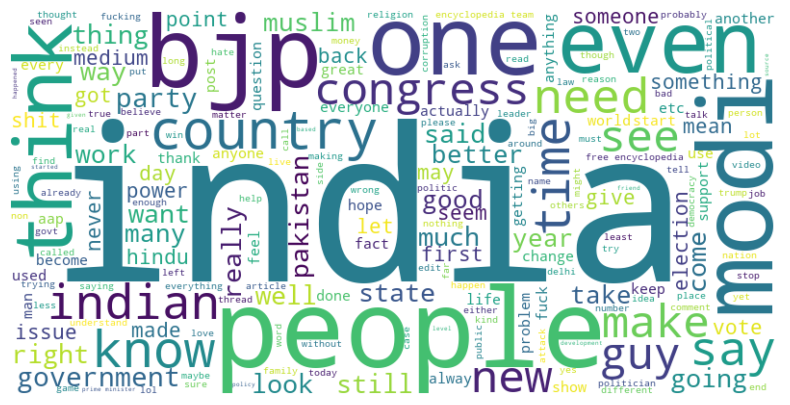

In [67]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(
        " ".join(text)
    )
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()


plot_word_cloud(df["clean_comment"])

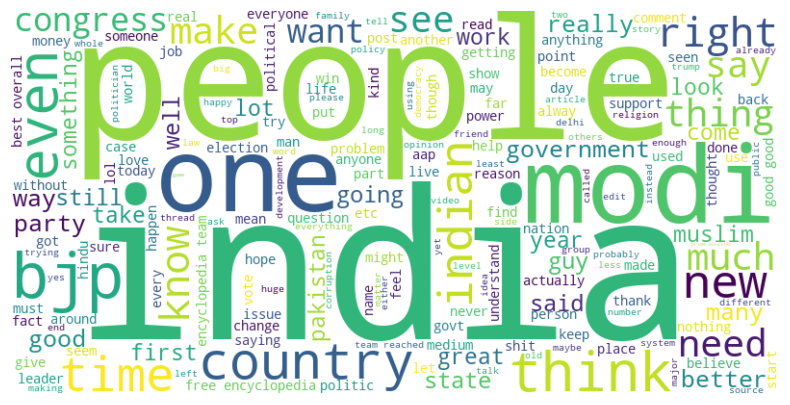

In [68]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df[df['category'] == "positive"]['clean_comment'])

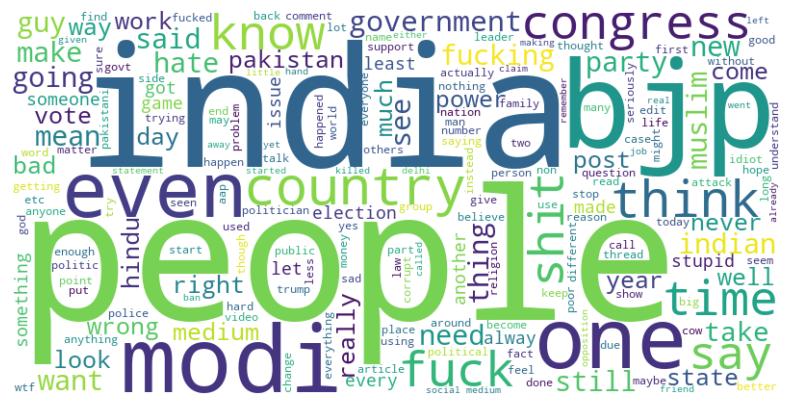

In [69]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(
        " ".join(text)
    )
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()


plot_word_cloud(df[df["category"] == "negative"]["clean_comment"])

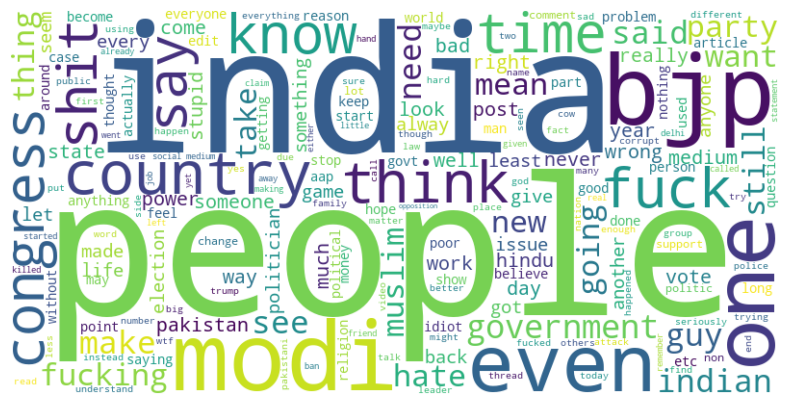

In [70]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df[df['category'] == "negative"]['clean_comment'])

In [71]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns


def plot_top_n_words(df, text_col="clean_comment", n=20):
    """Plot the top N most frequent words in a dataframe column."""

    # Ensure valid text and combine all words
    all_words = df[text_col].dropna().astype(str).str.cat(sep=" ").split()

    # Count word frequencies
    word_counts = Counter(all_words).most_common(n)

    # Unpack words and counts
    words, counts = zip(*word_counts) if word_counts else ([], [])

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words))

    plt.title(f"Top {n} Most Frequent Words")
    plt.xlabel("Frequency")
    plt.ylabel("Words")

    plt.tight_layout()
    plt.show()

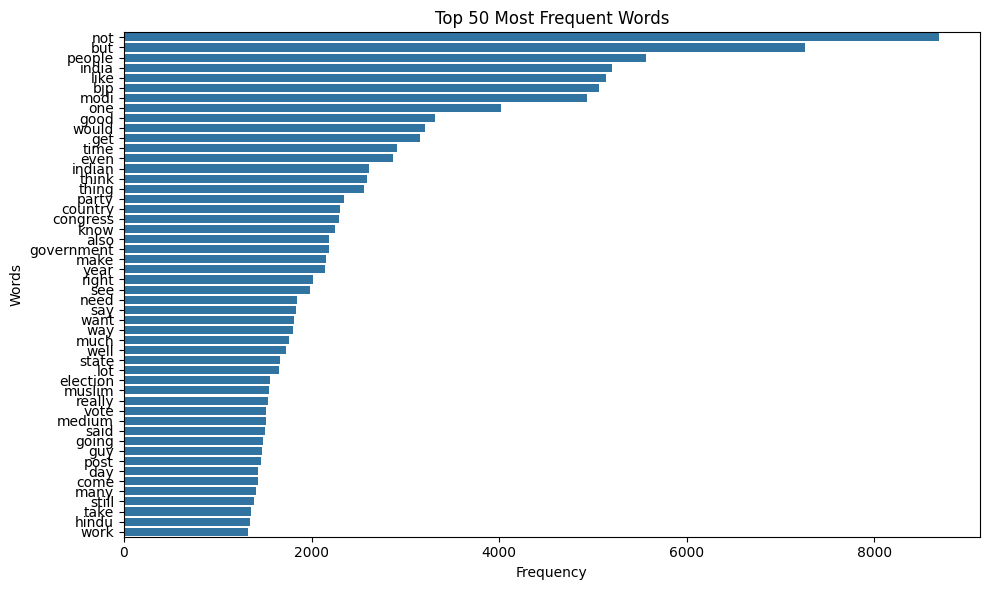

In [72]:
# Example usage
plot_top_n_words(df, n=50)

In [73]:
from collections import defaultdict, Counter
import matplotlib.pyplot as plt


def plot_top_n_words_by_category(
    df, text_col="clean_comment", cat_col="category", n=20, start=0
):
    """Plot top N words with sentiment-wise stacked frequency."""

    # word -> {category -> count}
    word_counts = defaultdict(lambda: defaultdict(int))

    # Build frequency dictionary
    for text, cat in zip(df[text_col].fillna(""), df[cat_col]):
        words = str(text).split()
        for w in words:
            word_counts[w][cat] += 1

    # Total frequency per word
    total_counts = {
        word: sum(cat_counts.values()) for word, cat_counts in word_counts.items()
    }

    # Get top words
    top_words = sorted(total_counts.items(), key=lambda x: x[1], reverse=True)[
        start : start + n
    ]
    top_words = [w for w, _ in top_words]

    # Extract stacked values
    neg = [word_counts[w].get("negative", 0) for w in top_words]
    neu = [word_counts[w].get("neutral", 0) for w in top_words]
    pos = [word_counts[w].get("positive", 0) for w in top_words]

    # Plot
    plt.figure(figsize=(12, 8))

    plt.barh(top_words, neg, color="red", label="Negative")
    plt.barh(top_words, neu, left=neg, color="gray", label="Neutral")
    plt.barh(
        top_words,
        pos,
        left=[i + j for i, j in zip(neg, neu)],
        color="green",
        label="Positive",
    )

    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.title(f"Top {n} Words by Sentiment Category")
    plt.legend()
    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

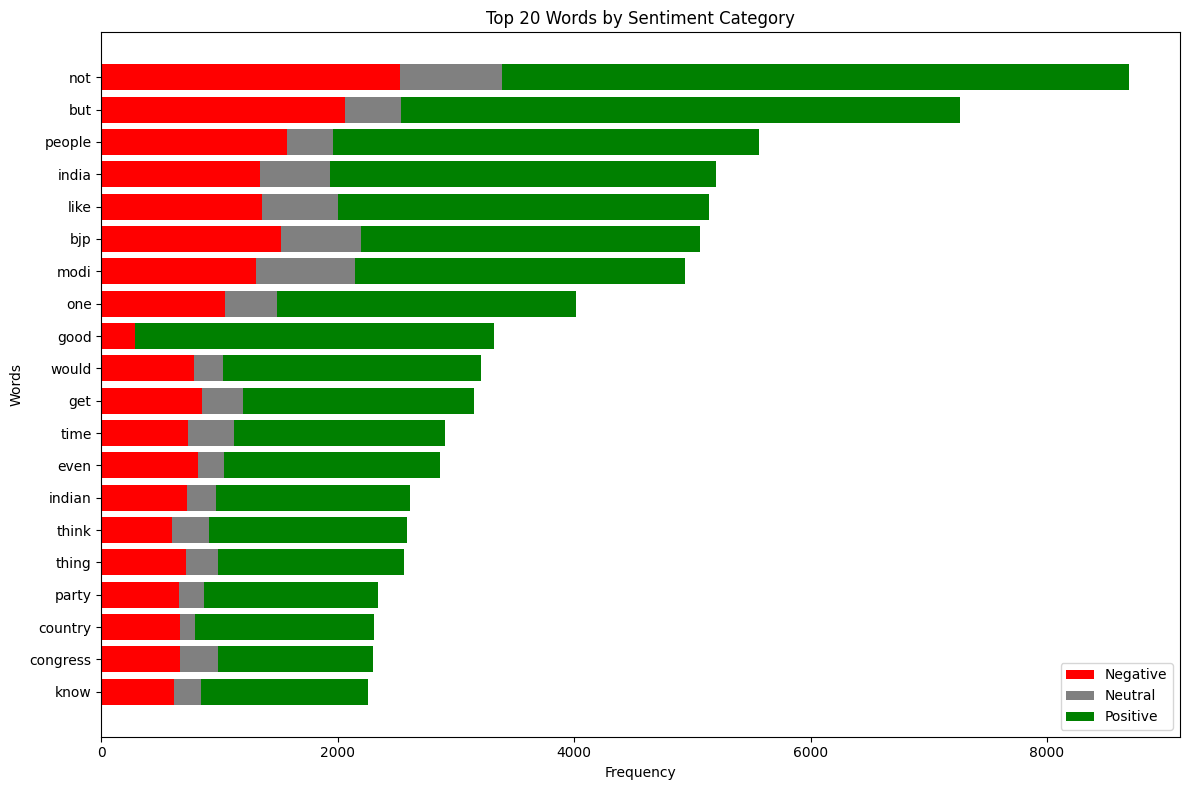

In [74]:
plot_top_n_words_by_category(df, n=20)

In [76]:
df.shape

(36793, 7)